# Inference and Evaluation of Saccharomyces Cerevisiae FluxTransformers

Explore and visualize the behavior of a pretrained FluxTransformer model on Saccharomyces Cerevisiae - yeast9 metabolism. Includes loss curves, diagnostic plots for chosen fluxes, PCA and t-SNE plots, and flux metrics.

In [3]:
import os
import re
from datetime import date

import torch
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

from yeast9_data import load_data, prepare_tensors, set_seed
from flux_transformer_rs import FluxTransformer
from yeast9_reactions import inputs

%matplotlib inline
pd.set_option('display.max_rows', None)

In [4]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [15]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")

    if log_scale:
        plt.yscale('log')
        
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [95]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None, model_name=None, sampling_hint=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""
    residuals = y_true - y_pred
    display_label = str(label)
    label_map = {
        'r_2111': 'Biomass',
    }
    display_label = label_map.get(display_label, display_label)

    def _token_to_float_str(token):
        if token is None:
            return None
        t = str(token).replace('_', '.')
        try:
            v = float(t)
            return f"{v:g}"
        except ValueError:
            return None

    def _extract_value(patterns, text):
        if not text:
            return None
        for pat in patterns:
            m = re.search(pat, text, flags=re.IGNORECASE)
            if m:
                val = _token_to_float_str(m.group(1))
                if val is not None:
                    return val
        return None

    model_name_str = '' if model_name is None else str(model_name)
    hint_str = '' if sampling_hint is None else str(sampling_hint)
    combined = f"{model_name_str} {hint_str}".lower()

    subset_ratio = _extract_value([
        r'rs([0-9]+(?:_[0-9]+)?)',
        r'sample([0-9]+(?:_[0-9]+)?)',
        r'output\s*subset\s*ratio\s*=\s*([0-9]*\.?[0-9]+)',
    ], combined)

    strategy = 'uniform'
    details = []
    is_correlations = False
    corr_label = None
    corr_prob = None
    if 'sample' in combined:
        strategy = 'sample driven'
        sample_prob = _extract_value([
            r'sample[_\s-]*prob\s*=\s*([0-9]*\.?[0-9]+)',
            r'sample[0-9]+(?:_[0-9]+)?_p([0-9]+(?:_[0-9]+)?)',
            r'_p([0-9]+(?:_[0-9]+)?)',
        ], combined)
        if sample_prob is None:
            sample_prob = '1'
        details.append(f"prob={sample_prob}")
    elif ('cov' in combined) or ('correlation' in combined) or ('_p' in model_name_str.lower() and 'rs' in model_name_str.lower()):
        strategy = 'correlations'
        is_correlations = True
        corr_label = 'signed corr' if ('signed' in combined or re.search(r'cov[23](?:_|\b)', model_name_str.lower())) else 'abs corr'
        corr_prob = _extract_value([
            r'cov[_\s-]*prob\s*=\s*([0-9]*\.?[0-9]+)',
            r'_p([0-9]+(?:_[0-9]+)?)',
        ], combined)
    elif re.search(r'rs[0-9]+(?:_[0-9]+)?', model_name_str.lower()):
        strategy = 'weighted'

    if is_correlations:
        meta_parts = []
        if subset_ratio is not None:
            meta_parts.append(f"ratio={subset_ratio}")
        meta_parts.append(corr_label)
        if corr_prob is not None:
            meta_parts.append(f"p={corr_prob}")
        ratio_suffix = f" ({', '.join(meta_parts)})"
    else:
        meta_parts = []
        if subset_ratio is not None:
            meta_parts.append(f"ratio={subset_ratio}")
        if details:
            meta_parts.append(f"{strategy} ({', '.join(details)})")
        else:
            meta_parts.append(strategy)
        ratio_suffix = f" ({', '.join(meta_parts)})"

    title_fs = 14
    label_fs = 13
    tick_fs = 11

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Pred: {display_label}{ratio_suffix}', fontsize=title_fs)
    axs[0, 0].set_xlabel('True value', fontsize=label_fs)
    axs[0, 0].set_ylabel('Predicted', fontsize=label_fs)
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {display_label}{ratio_suffix}', fontsize=title_fs)
    axs[0, 1].set_xlabel('True value', fontsize=label_fs)
    axs[0, 1].set_ylabel('Residuals', fontsize=label_fs)
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Error Distribution: {display_label}{ratio_suffix}', fontsize=title_fs)
    axs[1, 0].set_xlabel('Prediction Error', fontsize=label_fs)
    axs[1, 0].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Values: {display_label}{ratio_suffix}', fontsize=title_fs)
    axs[1, 1].set_xlabel('True Value', fontsize=label_fs)
    axs[1, 1].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 1].grid(True)

    for ax in axs.ravel():
        ax.tick_params(labelsize=tick_fs)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()
    plt.close()

In [94]:
def plot_flux(
    model,
    X_test,
    y_test, 
    input_cols,
    output_cols,
    flux_name: str,
    save_path=None,
    model_name=None,
    sampling_hint=None,
    batch_size=16,
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Plotting for a single flux column.
    """

    # find target column index
    try:
        target_idx = output_cols.index(flux_name) + len(input_cols)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    print(f"Plotting flux '{flux_name}' (column index {target_idx})")

    model = model.to(device)
    model.eval()

    pred_vals = []
    true_vals = []

    with torch.no_grad():
        for i in range(0, X_test.shape[0], batch_size):
            xb = X_test[i:i+batch_size].to(device)
            yb_true = y_test[i:i+batch_size]

            c = xb.unsqueeze(-1)

            yb_pred, _ = model(c)

            # Slice only the flux we care
            yb_pred_flux = yb_pred.squeeze(-1)[:, target_idx].detach().cpu().numpy()
            yb_true_flux = yb_true[:, target_idx].detach().cpu().numpy()

            pred_vals.append(yb_pred_flux)
            true_vals.append(yb_true_flux)

            if device.startswith('cuda'):
                torch.cuda.empty_cache()

    # concatenate all batches
    y_pred_flux = np.concatenate(pred_vals, axis=0)
    y_true_flux = np.concatenate(true_vals, axis=0)

    flux_r2 = r2_score(y_true_flux.ravel(), y_pred_flux.ravel())
    flux_mae = mean_absolute_error(y_true_flux.ravel(), y_pred_flux.ravel())
    flux_rmse = np.sqrt(np.mean((y_true_flux.ravel() - y_pred_flux.ravel()) ** 2))

    print(f"{flux_name} y_true range: {y_true_flux.min()} .. {y_true_flux.max()}")
    print(f"{flux_name} y_pred range: {y_pred_flux.min()} .. {y_pred_flux.max()}")
    print(f"{flux_name} R2:   {flux_r2:.4f}")
    print(f"{flux_name} MAE:  {flux_mae:.6f}")
    print(f"{flux_name} RMSE: {flux_rmse:.6f}")

    if model_name is None:
        model_name = globals().get('model_name', None)
    if sampling_hint is None:
        sampling_hint = globals().get('sampling_notes', None)
    if save_path:
        base, ext = os.path.splitext(save_path)
        model_part = '' if model_name is None else str(model_name)
        hint_part = '' if sampling_hint is None else str(sampling_hint)
        tag_source = f"{model_part}_{hint_part}".strip('_')
        if tag_source:
            safe_tag = re.sub(r'[^A-Za-z0-9._-]+', '_', tag_source).strip('_')
            save_path = f"{base}_{safe_tag}{ext or '.png'}"

    plot_diagnostics_2x2(
        y_true=y_true_flux,
        y_pred=y_pred_flux,
        label=flux_name,
        save_path=save_path,
        model_name=model_name,
        sampling_hint=sampling_hint
    )


In [18]:
def calculate_metrics(model, X_test, y_test, inputs, batch_size=16, device=None):
    """
    Compute overall metrics (R2, MAE, RMSE) on the output columns in mini-batches.
    """
    n_inputs = len(inputs) if not isinstance(inputs, int) else inputs
    device = device or next(model.parameters()).device

    model.eval()
    preds_list, trues_list = [], []

    with torch.no_grad():
        for i in range(0, X_test.size(0), batch_size):
            xb = X_test[i:i+batch_size].to(device)
            yb = y_test[i:i+batch_size].to(device)

            # forward pass
            pb, _ = model(xb.unsqueeze(-1))  # [B, V, 1]

            if yb.dim() == 2:
                yb = yb.unsqueeze(-1)

            preds_list.append(pb[:, n_inputs:, 0].cpu())
            trues_list.append(yb[:, n_inputs:, 0].cpu())

    pred_outputs = torch.cat(preds_list).numpy()
    true_outputs = torch.cat(trues_list).numpy()

    # compute metrics
    r2 = r2_score(true_outputs.ravel(), pred_outputs.ravel())
    mae = mean_absolute_error(true_outputs.ravel(), pred_outputs.ravel())
    rmse = np.sqrt(np.mean((true_outputs.ravel() - pred_outputs.ravel()) ** 2))

    print(f"Overall R2: {r2:.4f}")
    print(f"Overall MAE: {mae:.4f}")
    print(f"Overall RMSE: {rmse:.4f}")

    return {"r2": r2, "mae": mae, "rmse": rmse}

In [19]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Load data

In [20]:
# Load data using the same function as during training
set_seed()

DATA_PATH = f"./data/yeast9_test_data.csv"

#X, y, input_cols, output_cols = load_data(data_info['dataset'])
X, y, input_cols, output_cols = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)


Loaded data with 49393 samples from ./data/yeast9_test_data.csv
Number of input features: 64
Number of output targets: 4131
Training samples: 39514
Test samples: 9879


## Plot Results

## Sampling strategy weighted

### Output subset ratio = 0.2

Using weights, T = 5

In [21]:
model_name = "yeast9_d128_h8_l3_ff1024_rs0_2"
sampling_notes = "Using weights, T = 5"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d128_h8_l3_ff1024_rs0_2/yeast9_d128_h8_l3_ff1024_rs0_2_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 1,532,705

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


In [22]:
model.eval()

today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

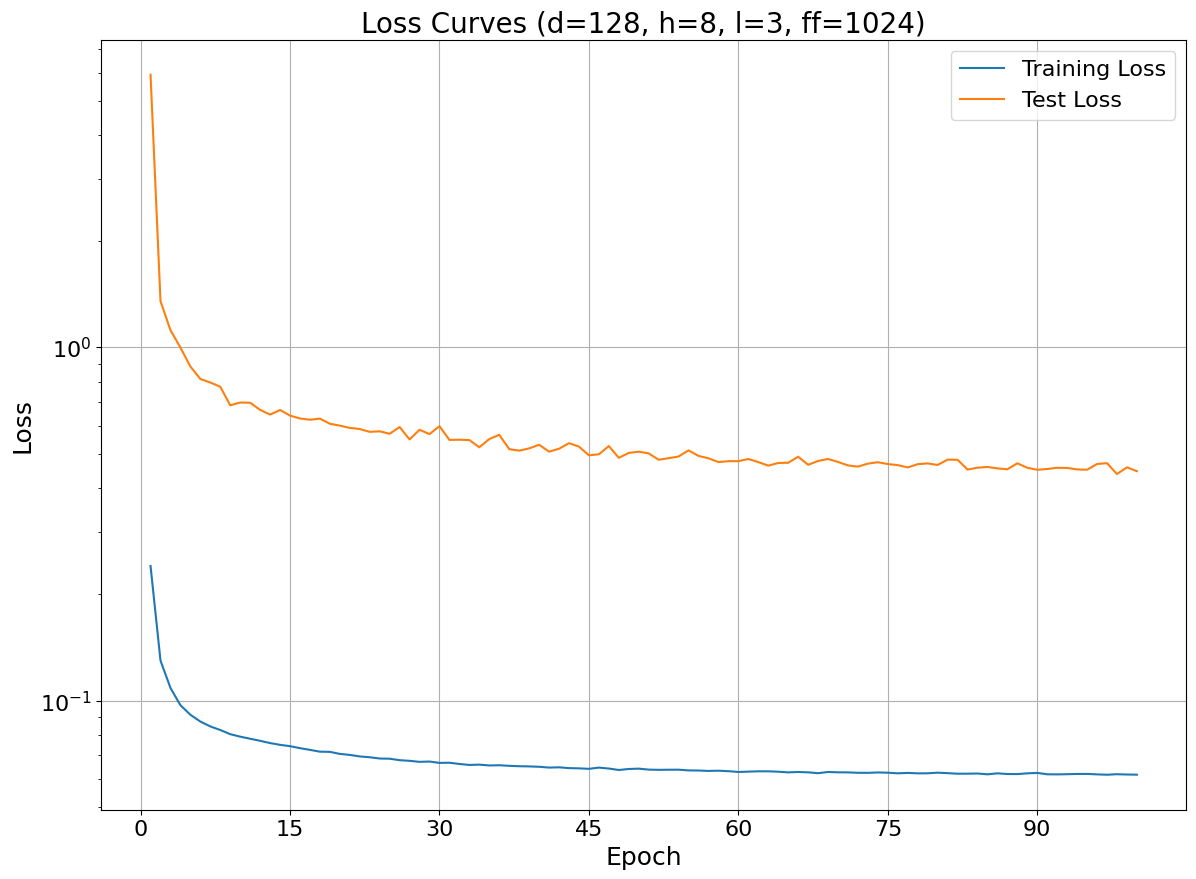

In [23]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: -0.12681059539318085 .. 2.573112964630127
r_2111 R2:   0.6527
r_2111 MAE:  0.287663
r_2111 RMSE: 0.331124


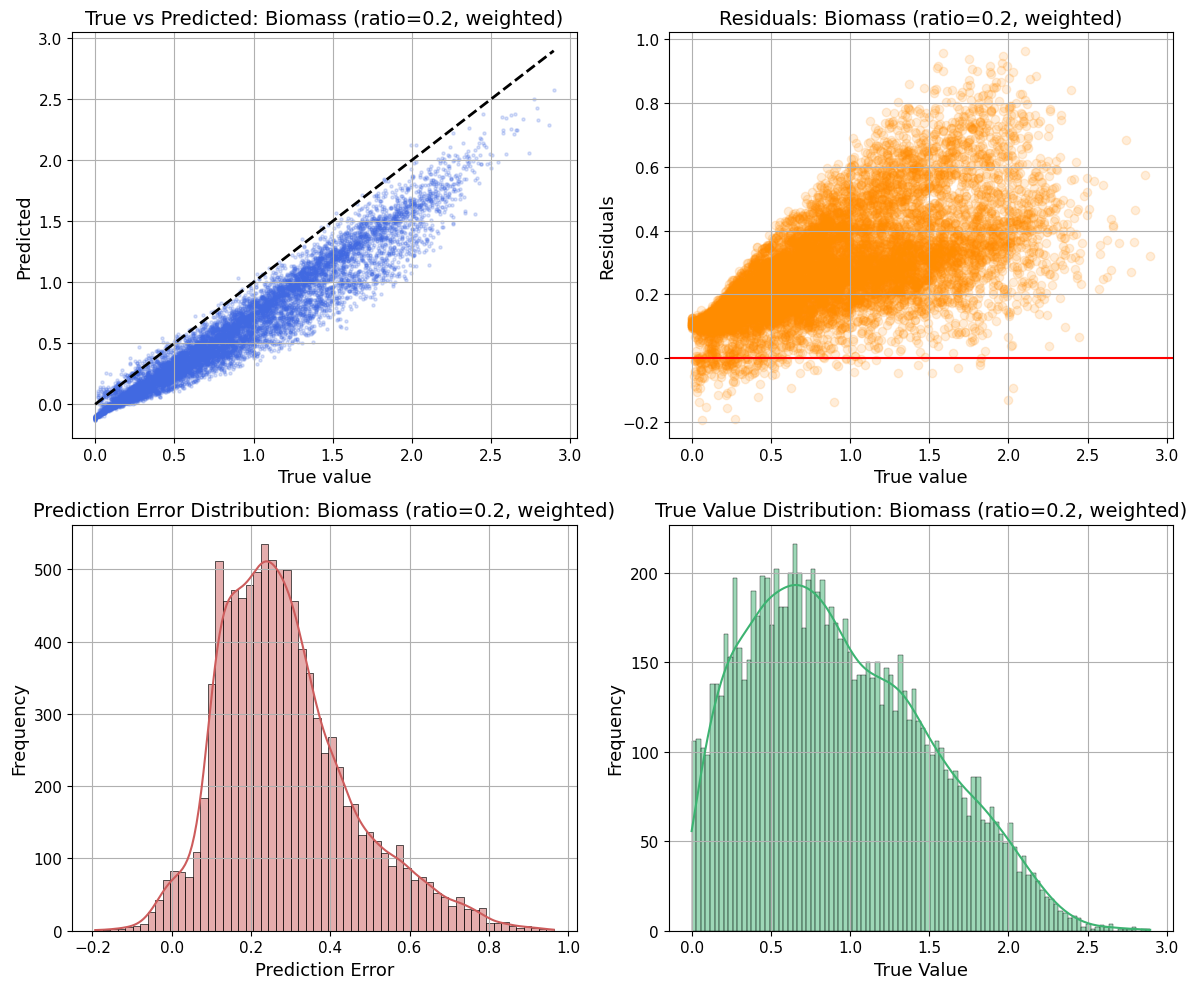

In [24]:
# r_2111: growth
# r_0438: ferrocytochrome-c:oxygen oxidoreductase
# r_1110: ADP/ATP transporter

diagnostics_to_plot = ['r_2111']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)

In [25]:
batch_size = 8

metrics = calculate_metrics(model, X_test, y_test, inputs, batch_size=batch_size, device=device)

Overall R2: 0.8720
Overall MAE: 0.1090
Overall RMSE: 1.2057


### Output subset ratio = 0.5

Using weights, T = 5

In [26]:
model_name = "yeast9_d128_h8_l3_ff1024_rs0_5"
sampling_notes = "Using weights, T = 5"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d128_h8_l3_ff1024_rs0_5/yeast9_d128_h8_l3_ff1024_rs0_5_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 1,532,705

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


In [27]:
model.eval()

today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

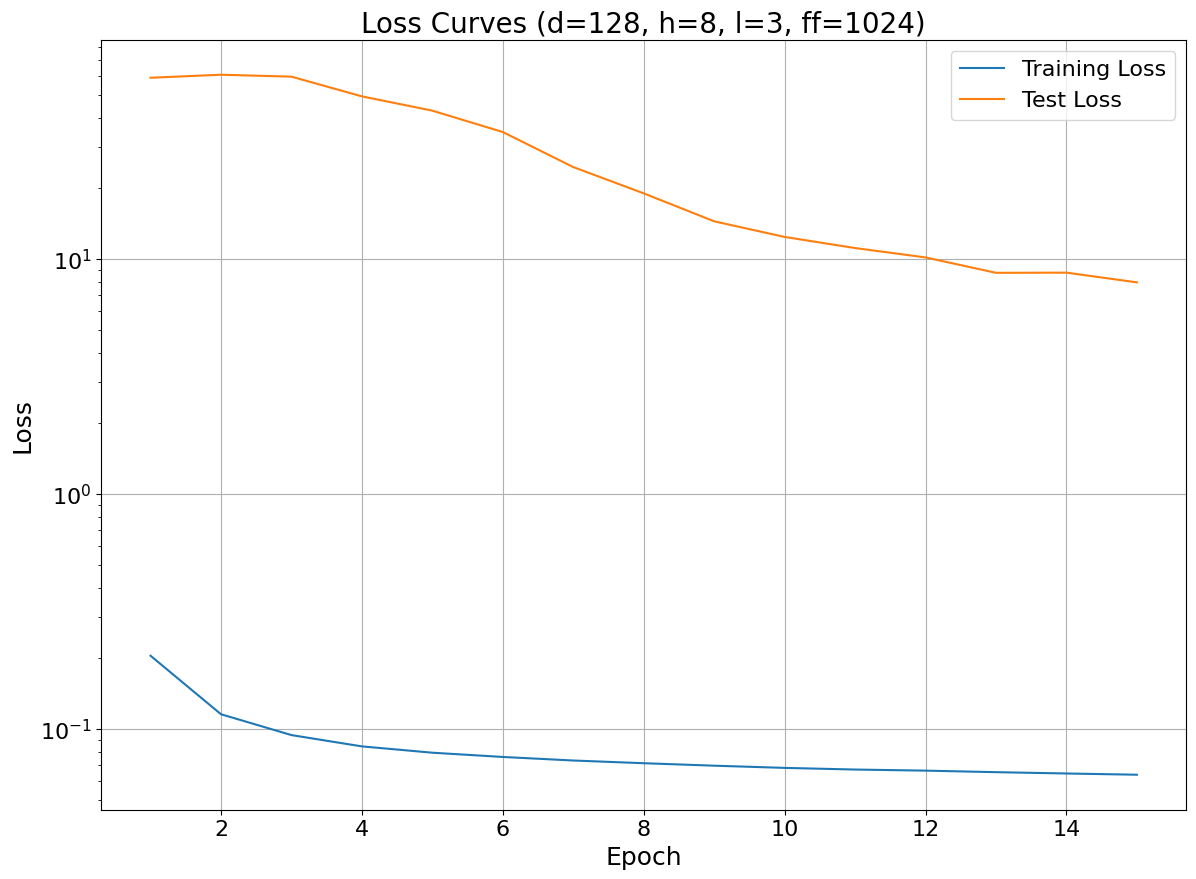

In [28]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: 0.06409764289855957 .. 1.9303810596466064
r_2111 R2:   0.5358
r_2111 MAE:  0.312873
r_2111 RMSE: 0.382830


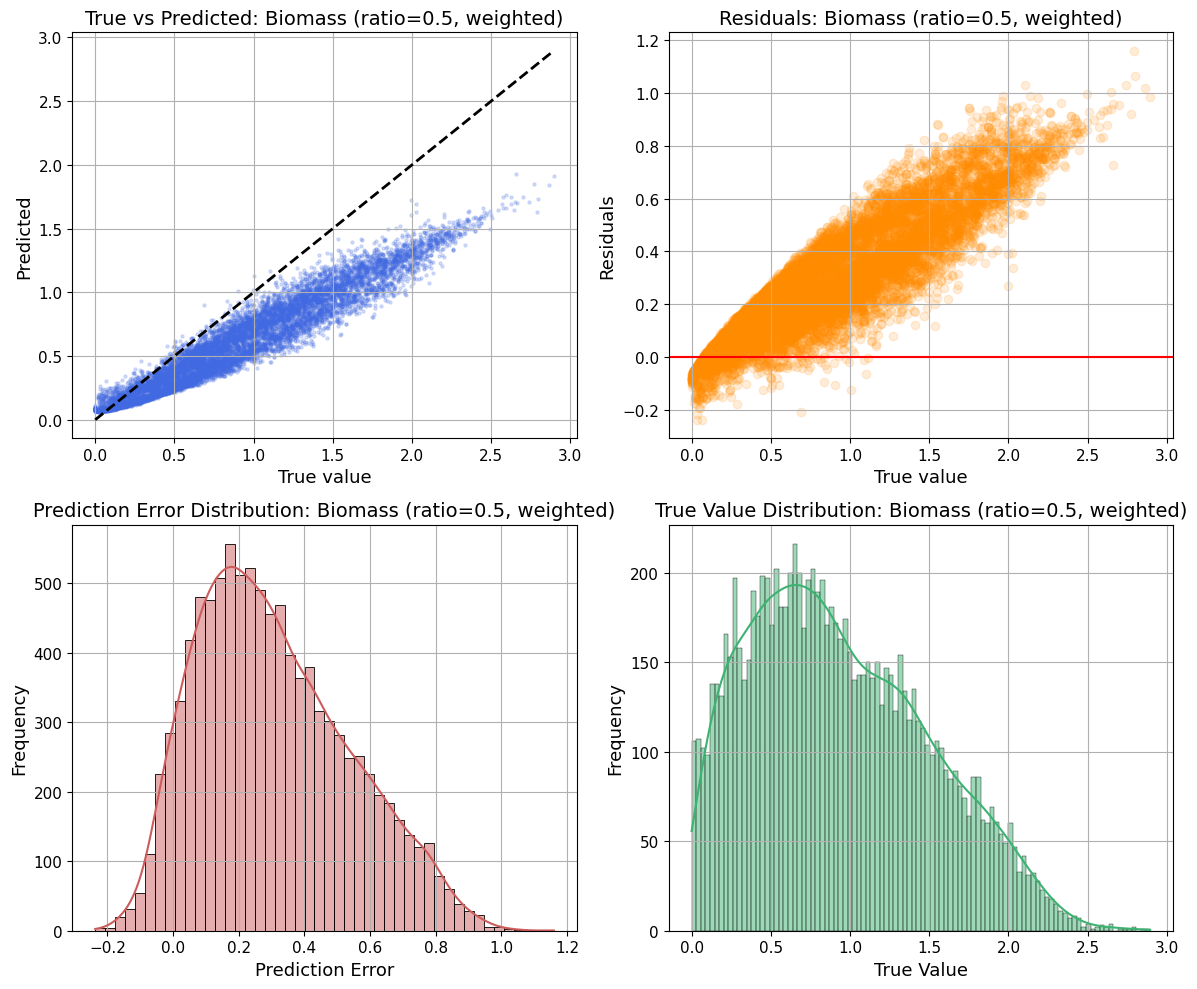

In [29]:
diagnostics_to_plot = ['r_2111']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)

In [30]:
batch_size = 8

metrics = calculate_metrics(model, X_test, y_test, inputs, batch_size=batch_size, device=device)

Overall R2: 0.8907
Overall MAE: 0.1023
Overall RMSE: 1.1145


## Sampling strategy: Correlations (signed)

### Output subset ratio = 0.4

Using correlation matrix, cov_prob = 0.7, signed correlations

In [38]:
model_name = "yeast9_d128_h8_l3_ff1024_rs0_4_p0_7"
sampling_notes = "Using correlation matrix, cov_prob = 0.7, signed correlations"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d128_h8_l3_ff1024_rs0_4_p0_7/yeast9_d128_h8_l3_ff1024_rs0_4_p0_7_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 1,532,705

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


In [39]:
model.eval()

today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

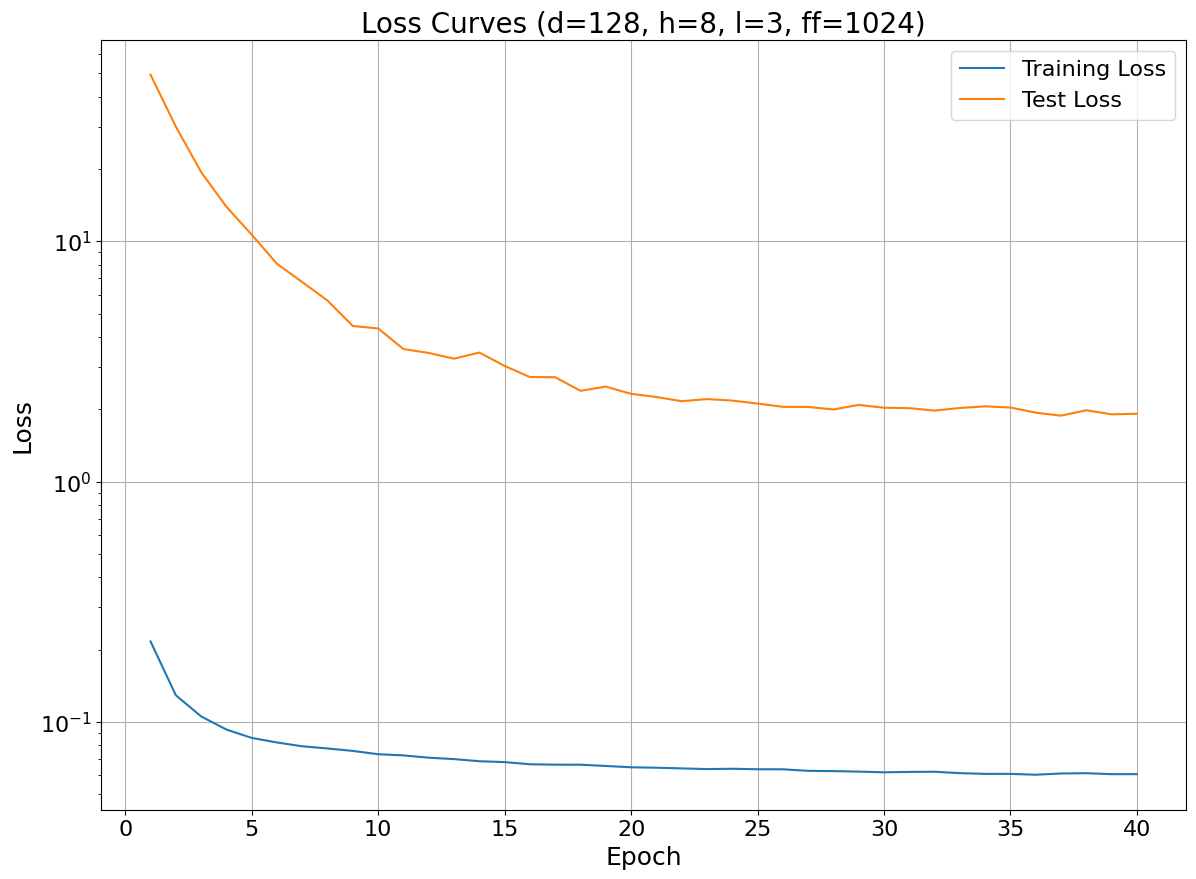

In [40]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: -0.007861733436584473 .. 2.4746556282043457
r_2111 R2:   0.9230
r_2111 MAE:  0.127163
r_2111 RMSE: 0.155937


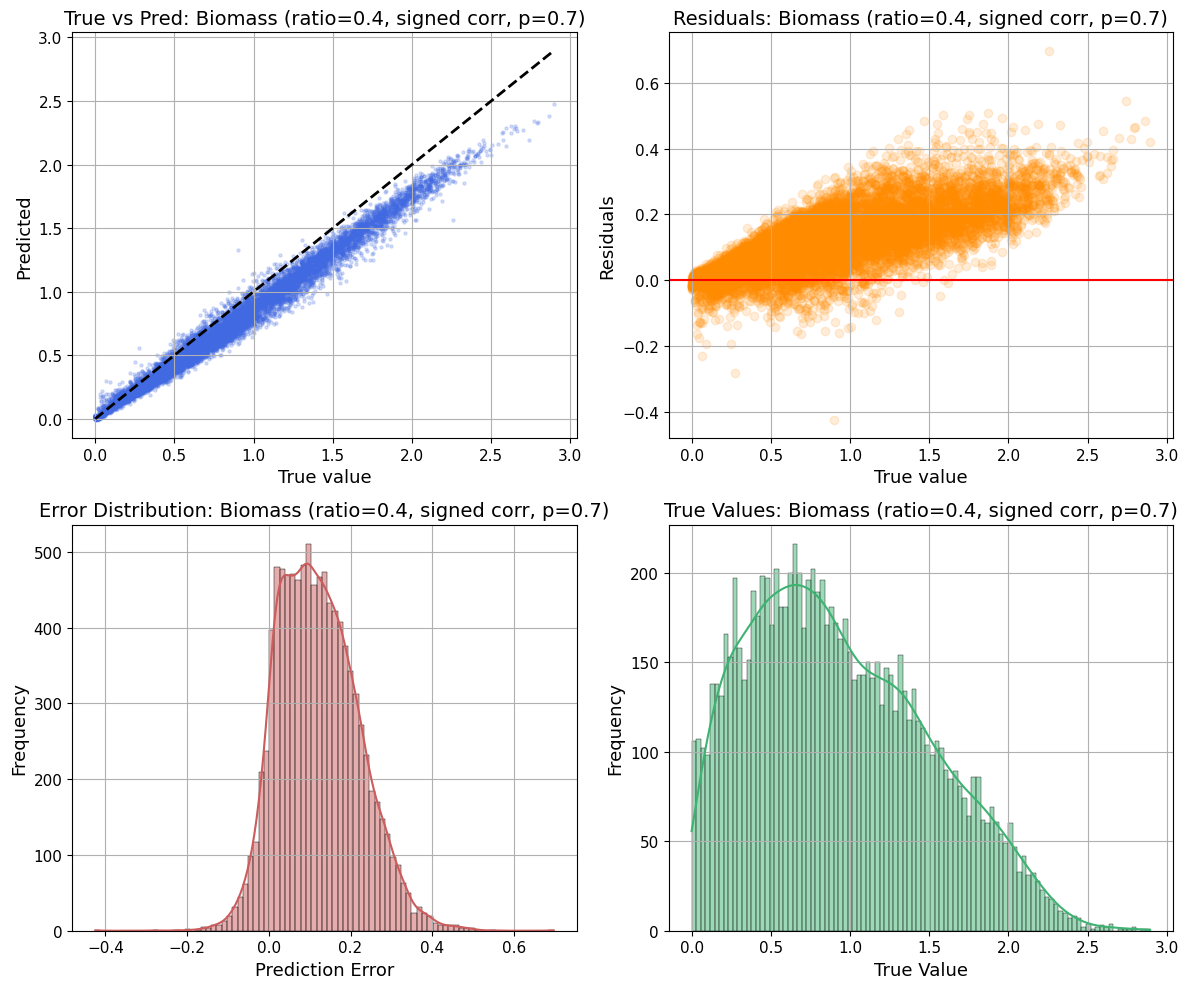

In [41]:
diagnostics_to_plot = ['r_2111']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=4)

In [42]:
batch_size = 8

metrics = calculate_metrics(model, X_test, y_test, inputs, batch_size=batch_size, device=device)

Overall R2: 0.9045
Overall MAE: 0.0820
Overall RMSE: 1.0416


### Output subset ratio = 0.5

Using correlation matrix, cov_prob = 1.0

In [96]:
model_name = "yeast9_d128_h8_l3_ff1024_rs0_5_cov3"
sampling_notes = "Using correlation matrix, cov_prob = 1.0"
checkpoint_path = f"./models/{model_name}/yeast9_d128_h8_l3_ff1024_rs0_5_cov1_0_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d128_h8_l3_ff1024_rs0_5_cov3/yeast9_d128_h8_l3_ff1024_rs0_5_cov1_0_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 1,532,705

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


In [97]:
model.eval()

today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

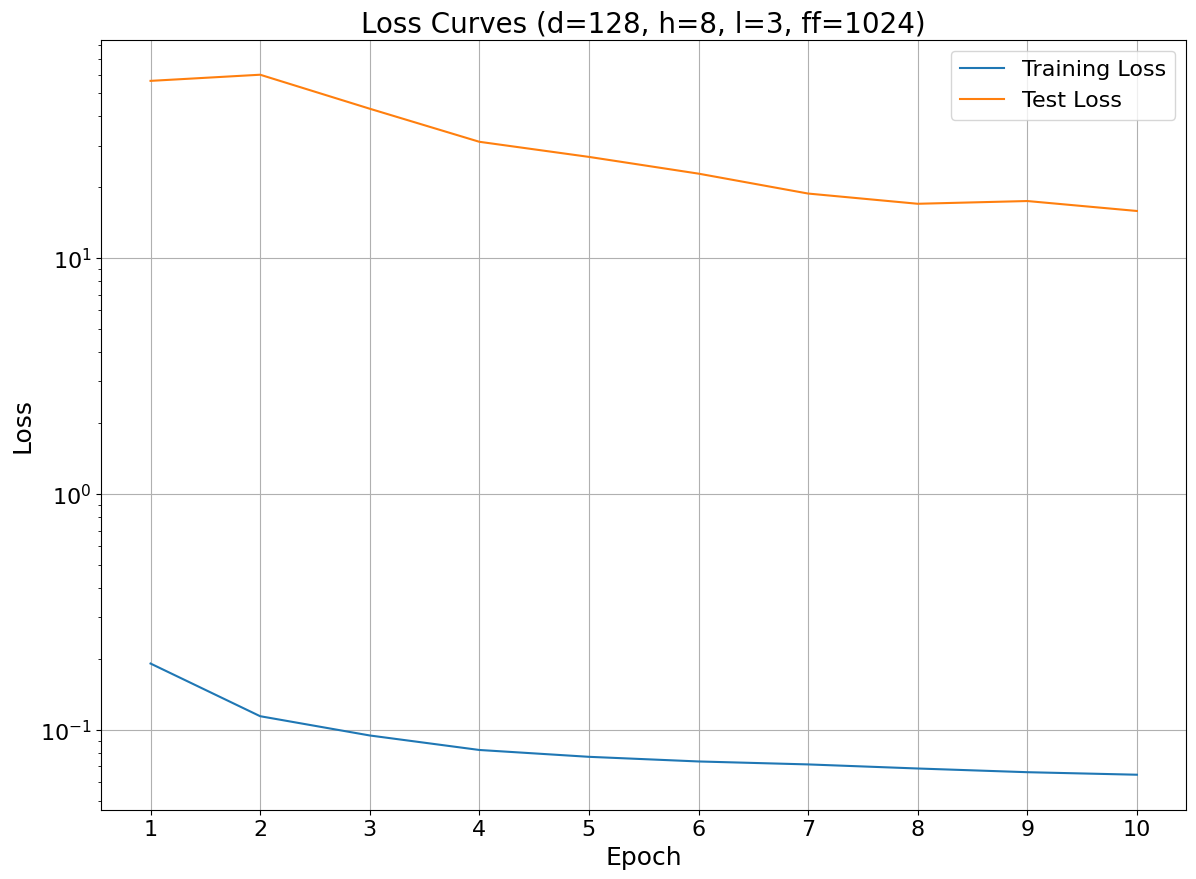

In [98]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: -0.003694474697113037 .. 2.0620815753936768
r_2111 R2:   0.5897
r_2111 MAE:  0.302872
r_2111 RMSE: 0.359913


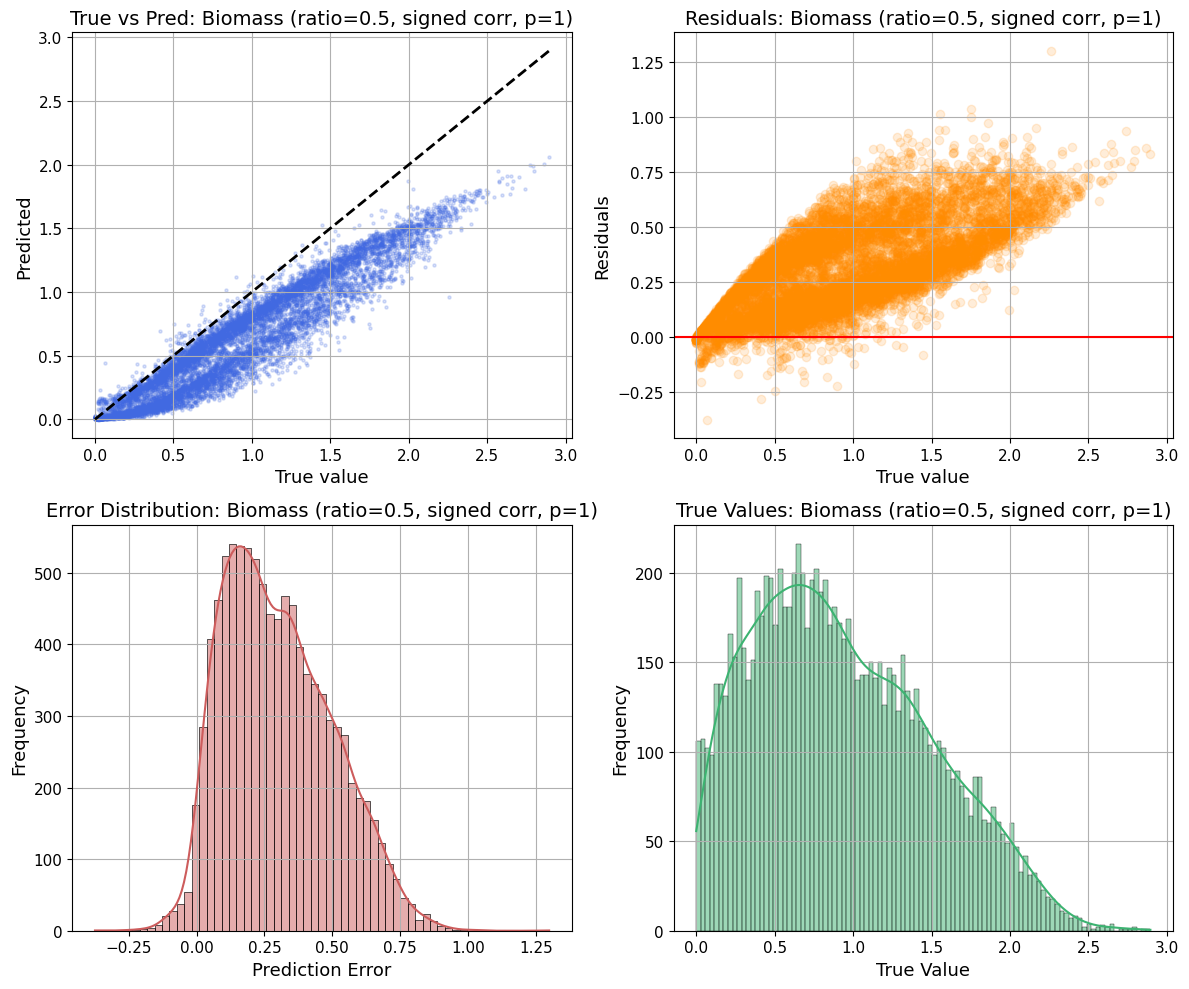

In [99]:
diagnostics_to_plot = ['r_2111']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=4)

In [100]:
batch_size = 8

metrics = calculate_metrics(model, X_test, y_test, inputs, batch_size=batch_size, device=device)

Overall R2: 0.8659
Overall MAE: 0.1223
Overall RMSE: 1.2343


### Output subset ratio = 0.5

Using correlation matrix, cov_prob = 0.7,  signed correlations

In [101]:
model_name = "yeast9_d128_h8_l3_ff1024_rs0_5_cov2"
sampling_notes = "Using correlation matrix, cov_prob = 0.7, signed correlations"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d128_h8_l3_ff1024_rs0_5_cov2/yeast9_d128_h8_l3_ff1024_rs0_5_cov2_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 1,532,705

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


In [102]:
model.eval()

today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

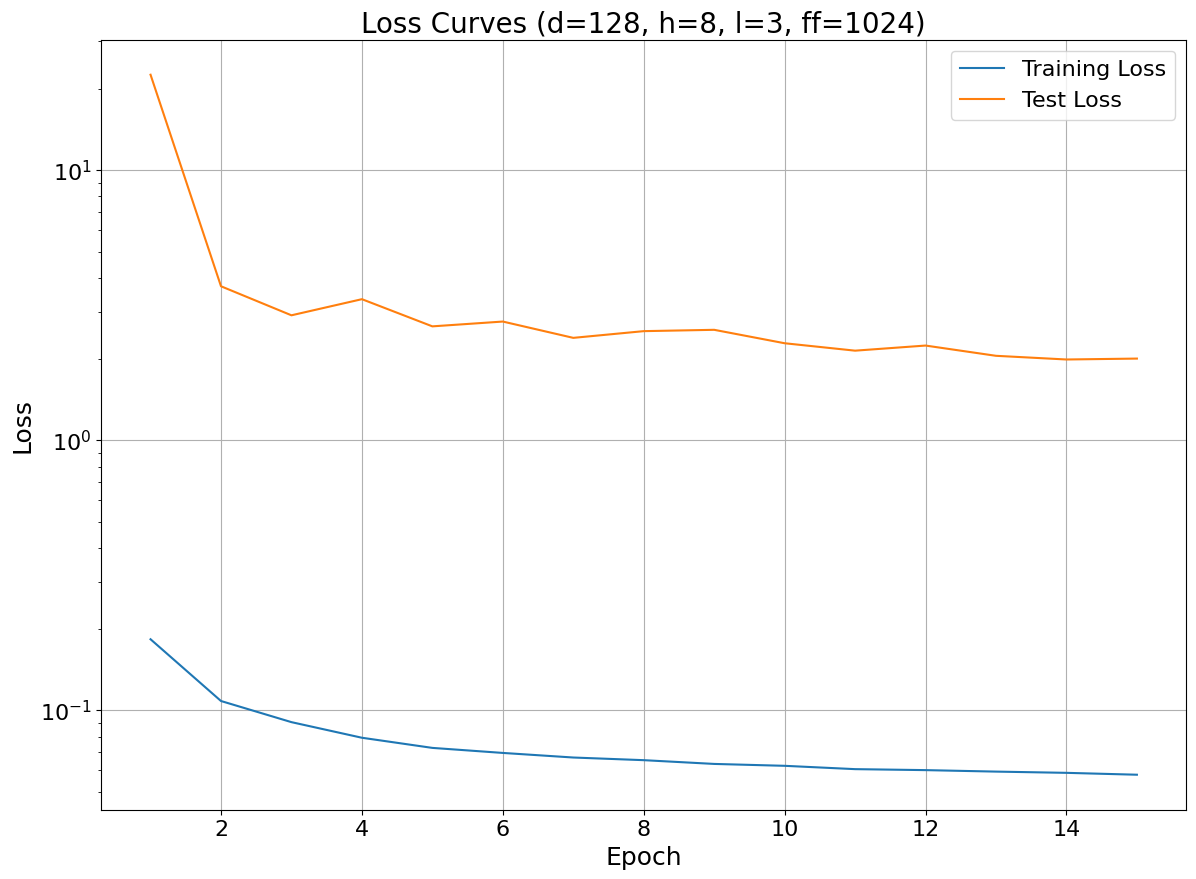

In [103]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: -0.034107208251953125 .. 2.70396089553833
r_2111 R2:   0.9782
r_2111 MAE:  0.056460
r_2111 RMSE: 0.082963


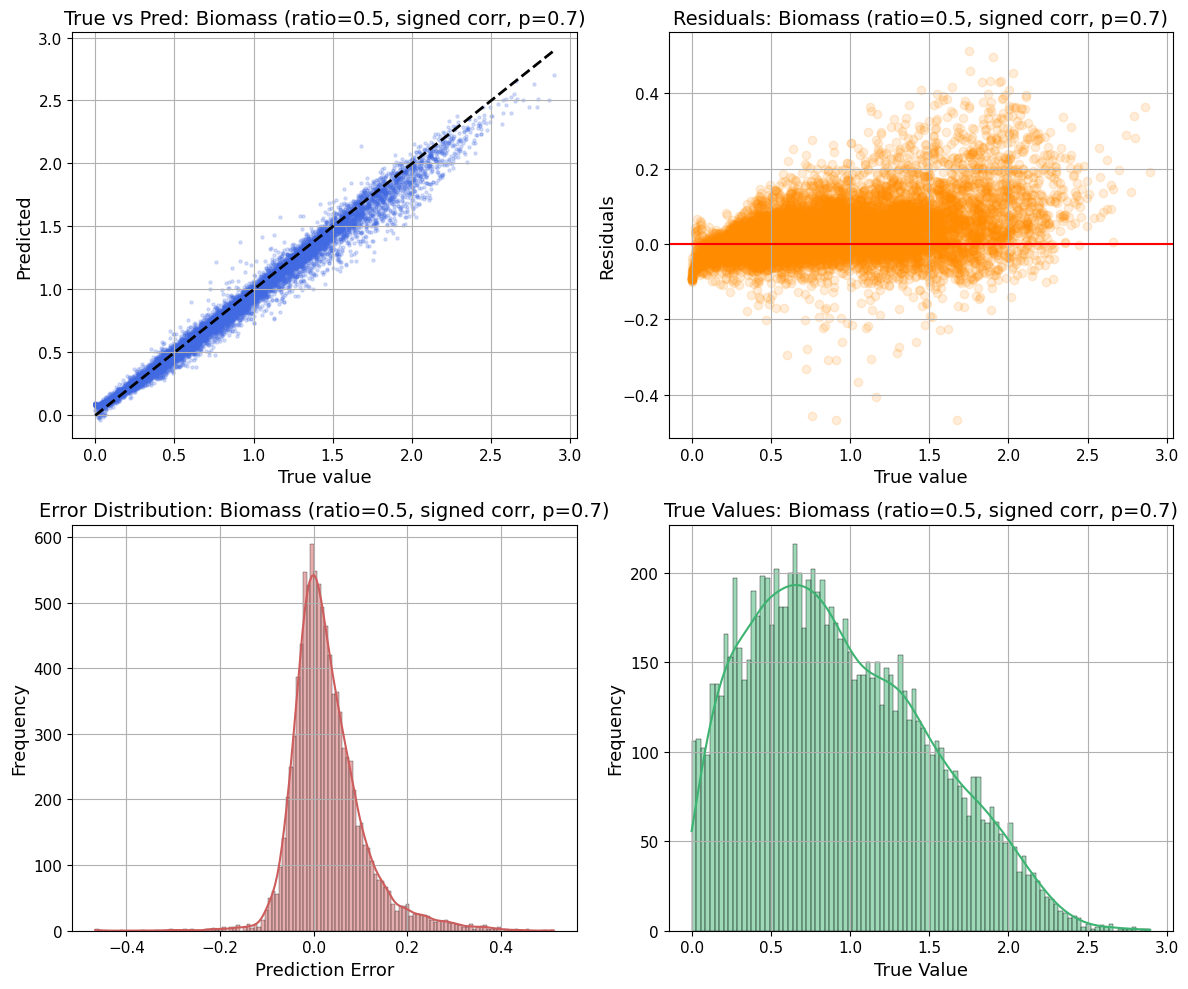

In [104]:
diagnostics_to_plot = ['r_2111']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=4)

In [56]:
batch_size = 8

metrics = calculate_metrics(model, X_test, y_test, inputs, batch_size=batch_size, device=device)

Overall R2: 0.9101
Overall MAE: 0.0745
Overall RMSE: 1.0105


## Sampling strategy: Correlations (absolute)

### Output subset ratio = 0.5

Using correlation matrix, cov_prob = 0.7, absolute correlations

In [57]:
model_name = "yeast9_d128_h8_l3_ff1024_rs0_5"
sampling_notes = "Using correlation matrix, cov_prob = 0.7, absolute correlations"
checkpoint_path = f"./models/{model_name}_cov3/{model_name}_cov0_7_2_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d128_h8_l3_ff1024_rs0_5_cov3/yeast9_d128_h8_l3_ff1024_rs0_5_cov0_7_2_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 1,532,705

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


In [58]:
model.eval()

today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

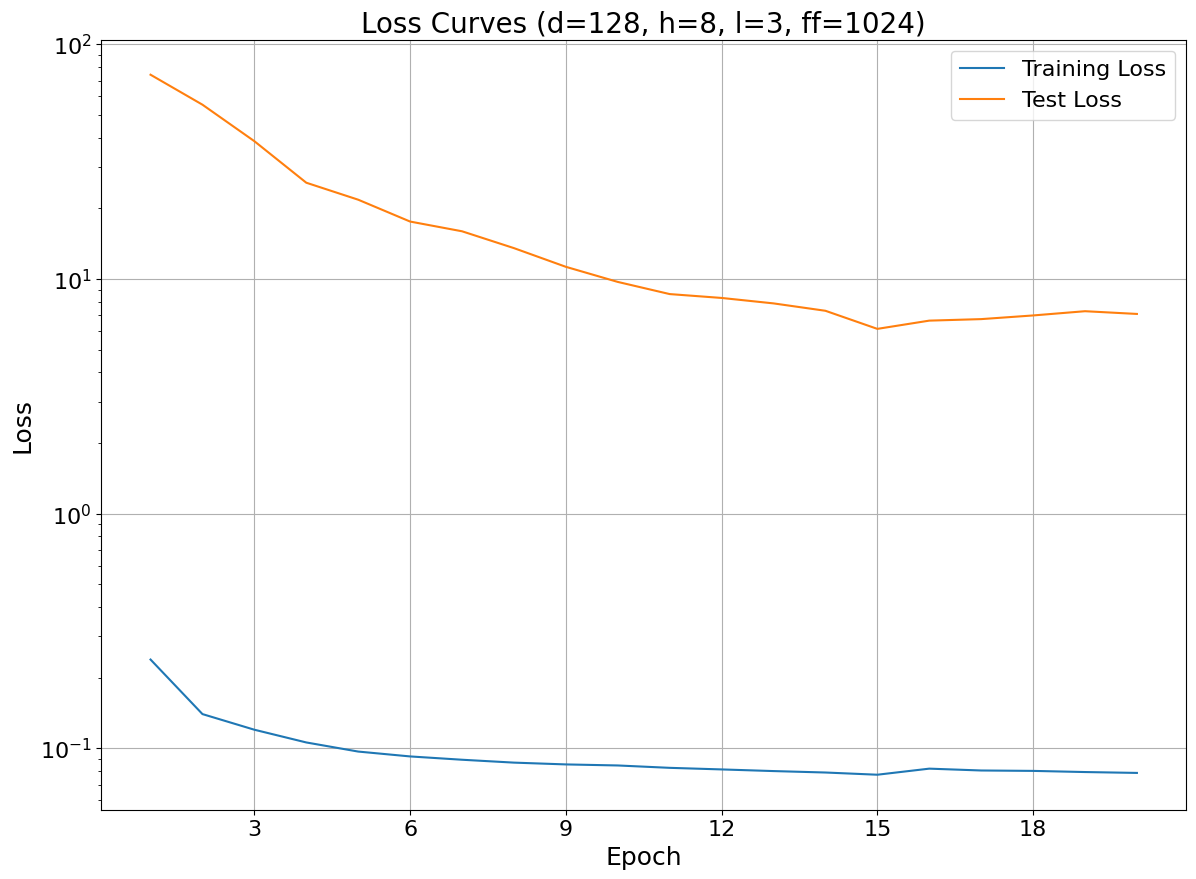

In [59]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: -0.09760057926177979 .. 2.545776844024658
r_2111 R2:   0.6877
r_2111 MAE:  0.282092
r_2111 RMSE: 0.313992


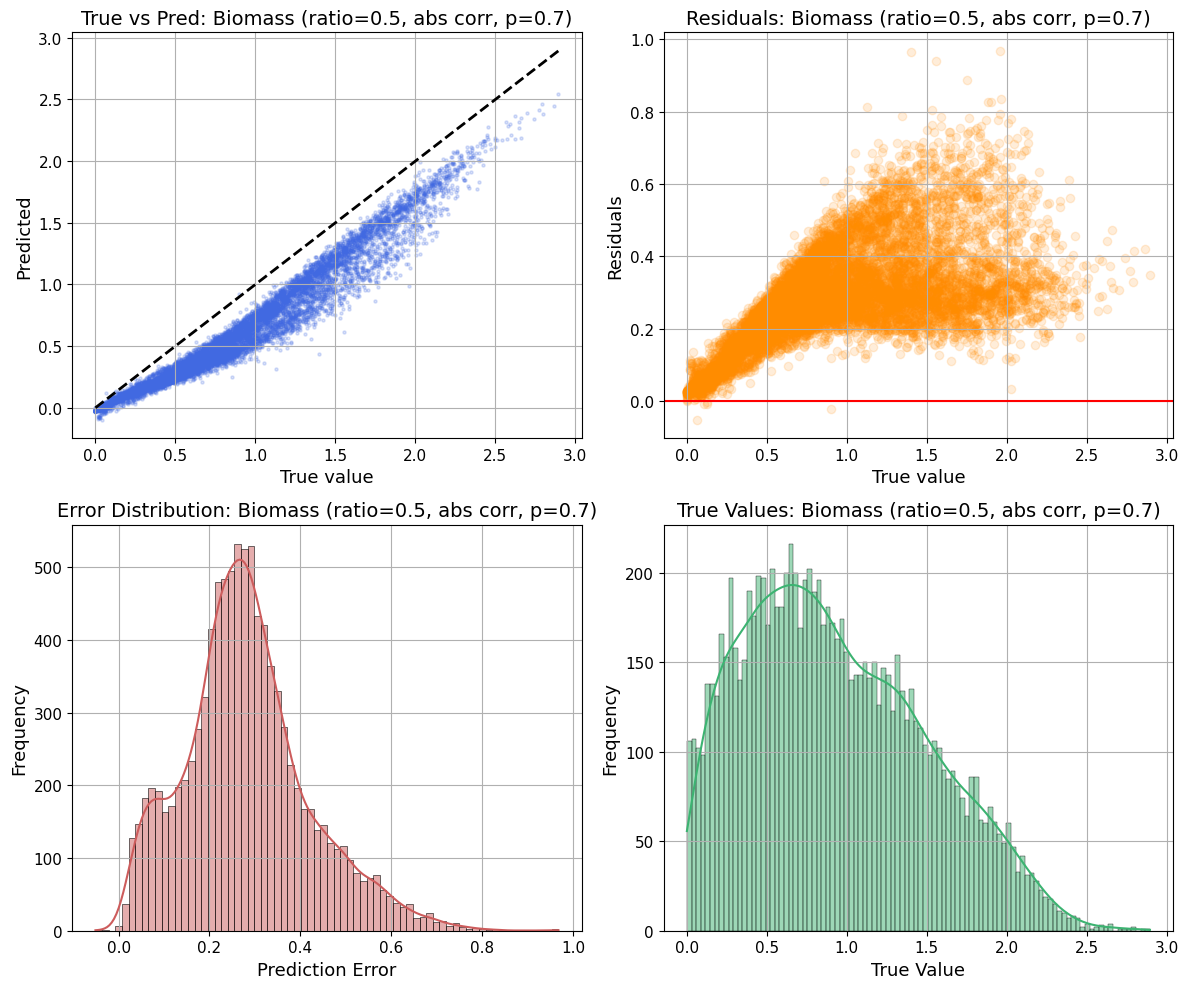

In [60]:
diagnostics_to_plot = ['r_2111']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=4)

In [61]:
batch_size = 8

metrics = calculate_metrics(model, X_test, y_test, inputs, batch_size=batch_size, device=device)

Overall R2: 0.8839
Overall MAE: 0.1077
Overall RMSE: 1.1487


### Output subset ratio = 0.5

Using correlation matrix, cov_prob = 0.3

In [62]:
model_name = "yeast9_d128_h8_l3_ff1024_rs0_5_cov"
sampling_notes = "Using correlation matrix, cov_prob = 0.3"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d128_h8_l3_ff1024_rs0_5_cov/yeast9_d128_h8_l3_ff1024_rs0_5_cov_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 1,532,705

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


In [63]:
model.eval()

today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

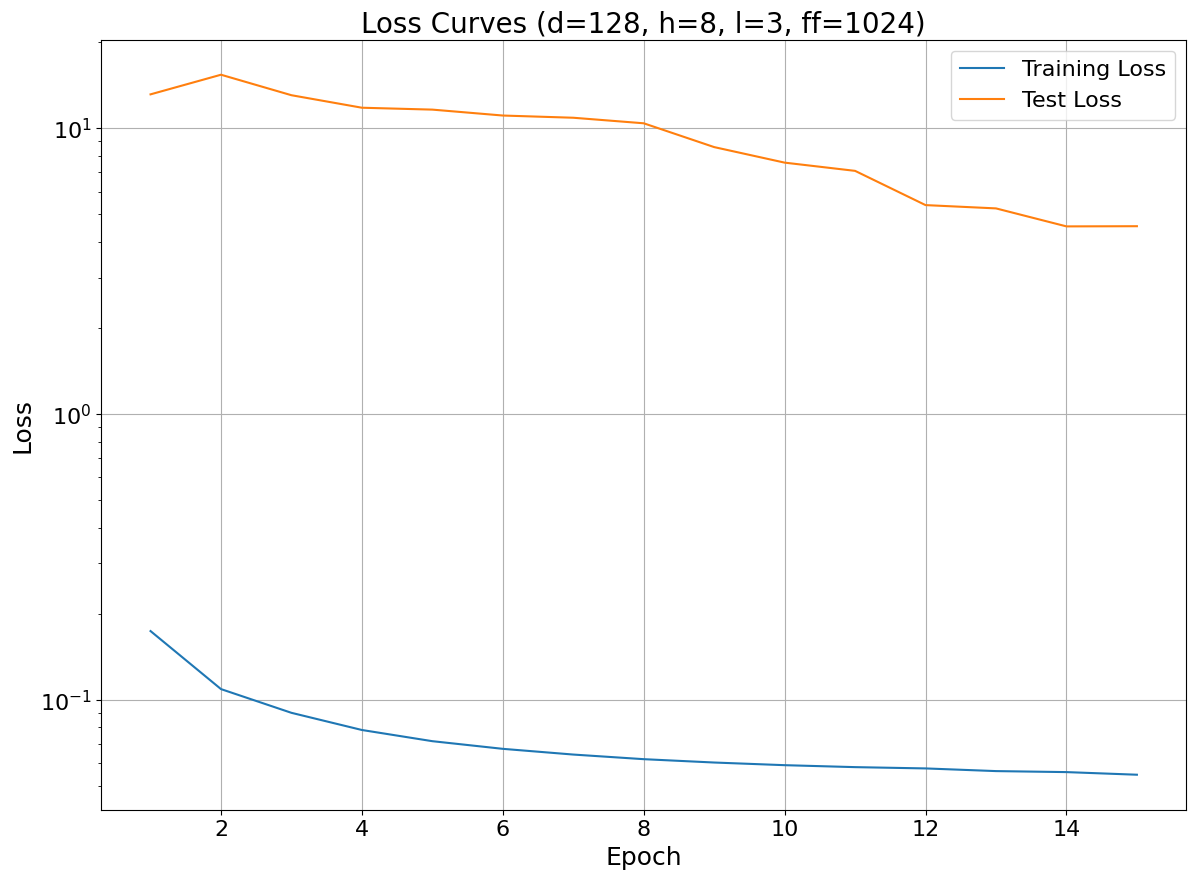

In [64]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: -0.15709984302520752 .. 2.1192054748535156
r_2111 R2:   0.8048
r_2111 MAE:  0.196686
r_2111 RMSE: 0.248277


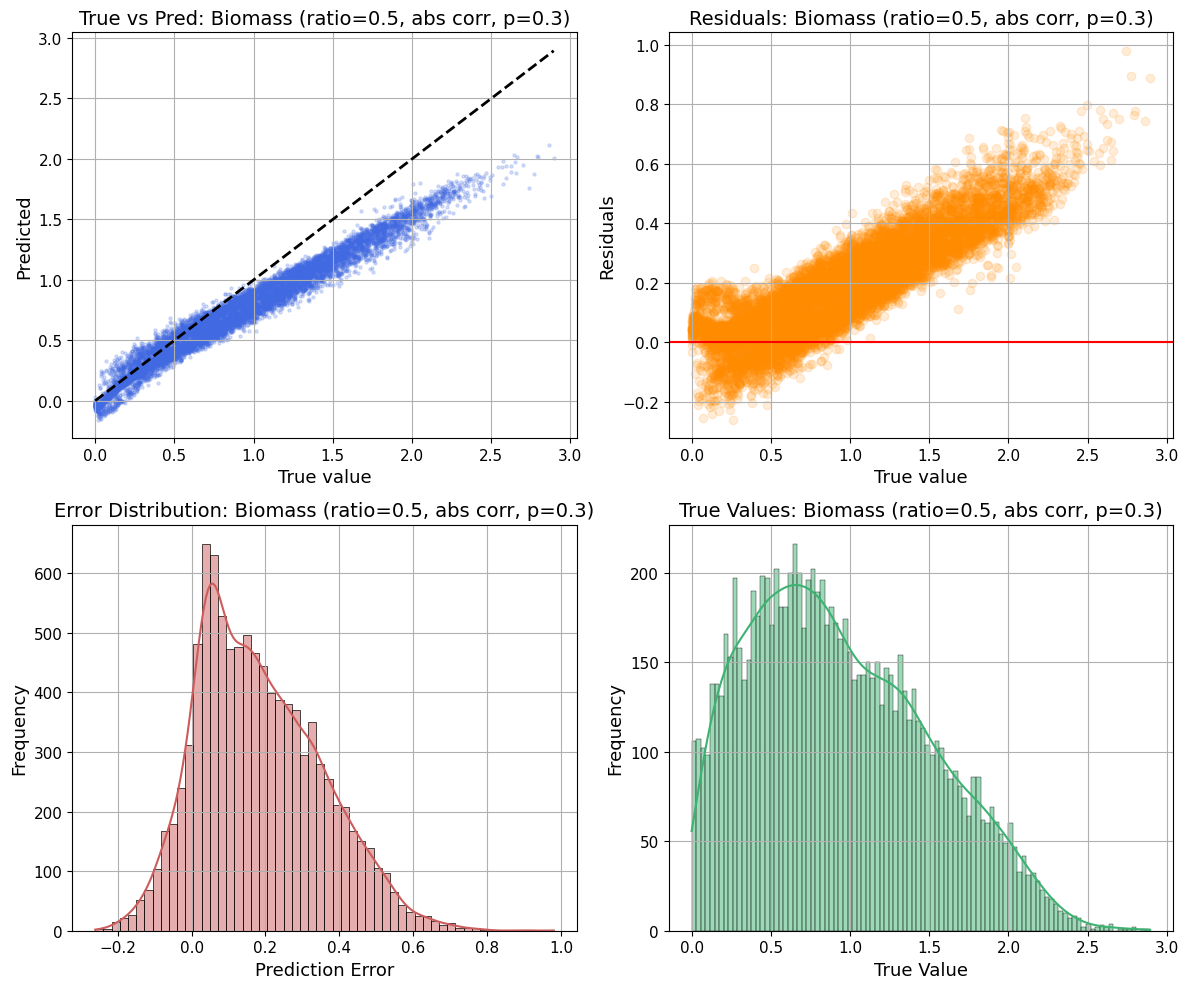

In [65]:
diagnostics_to_plot = ['r_2111']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)

In [66]:
batch_size = 8

metrics = calculate_metrics(model, X_test, y_test, inputs, batch_size=batch_size, device=device)

Overall R2: 0.9096
Overall MAE: 0.0795
Overall RMSE: 1.0137


## Sampling strategy: Sample-driven

### Output subset ratio = 0.5

Sample-driven training, sample_prob = 0.3

In [67]:
model_name = "yeast9_d128_h8_l3_ff1024_sample0_5_p0_3"
sampling_notes = "Sample-driven training, sample_prob = 0.3"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d128_h8_l3_ff1024_sample0_5_p0_3/yeast9_d128_h8_l3_ff1024_sample0_5_p0_3_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 1,532,705

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


In [68]:
model.eval()

today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

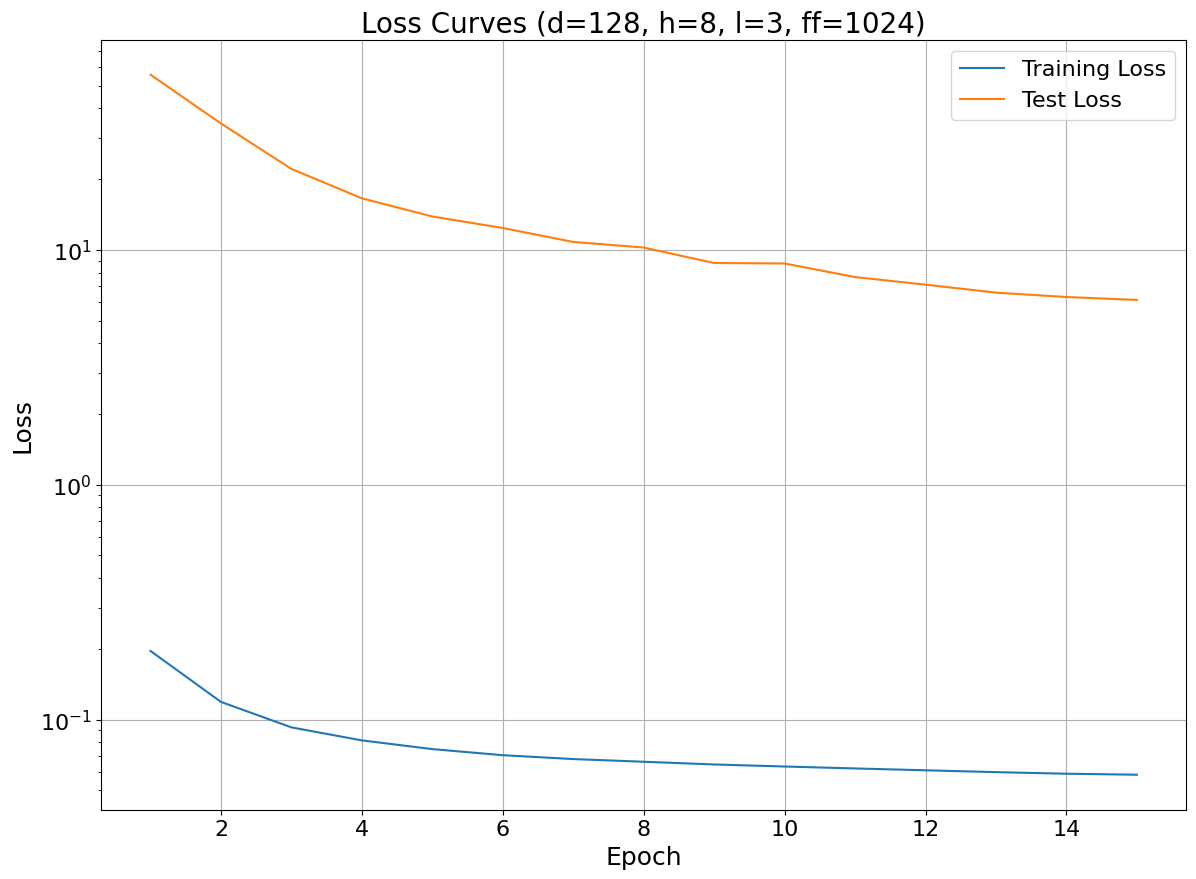

In [69]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: -0.028277307748794556 .. 2.3631906509399414
r_2111 R2:   0.8384
r_2111 MAE:  0.178416
r_2111 RMSE: 0.225857


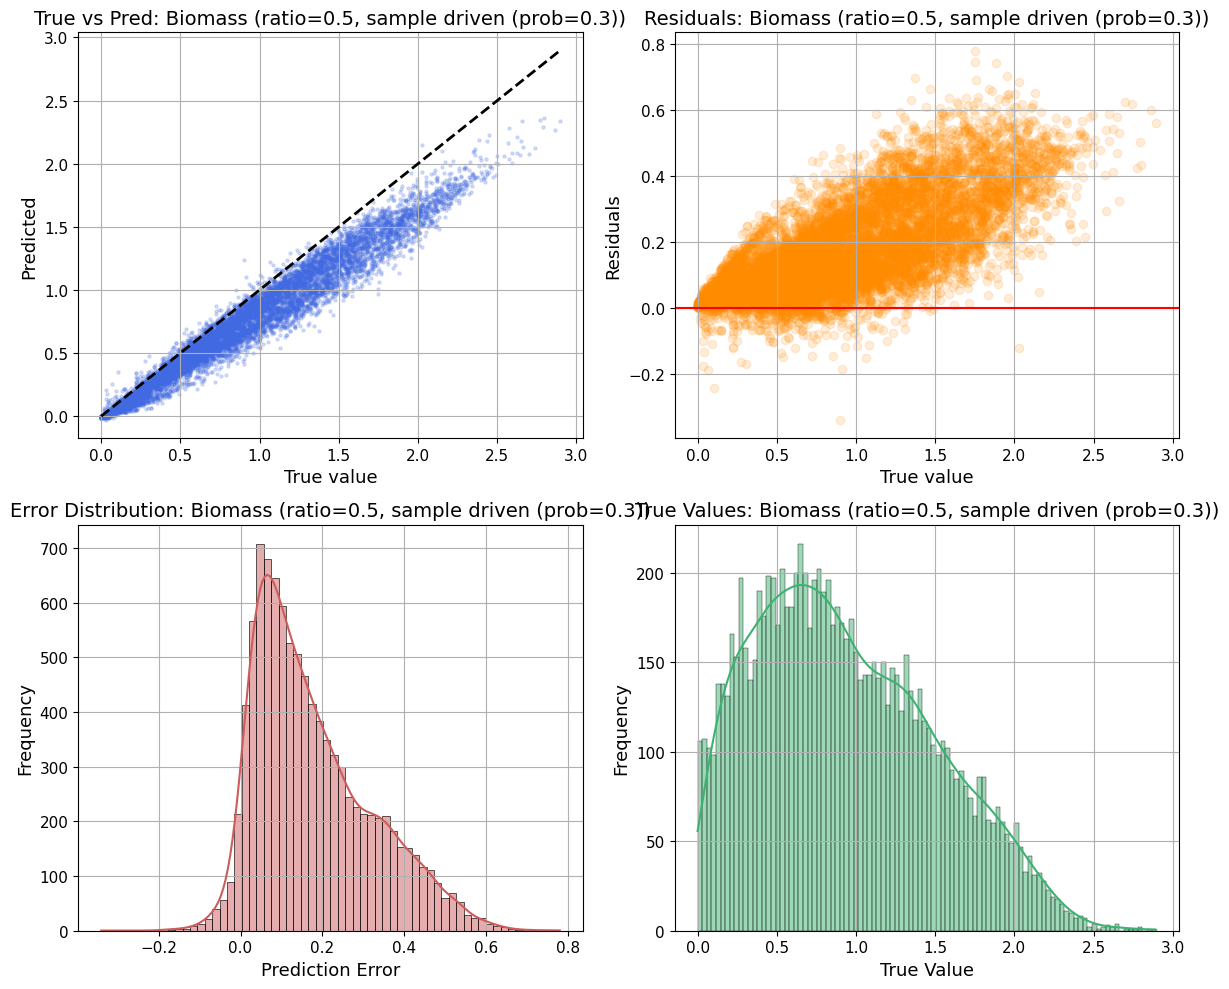

In [70]:
diagnostics_to_plot = ['r_2111']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)

In [71]:
batch_size = 8

metrics = calculate_metrics(model, X_test, y_test, inputs, batch_size=batch_size, device=device)

Overall R2: 0.8977
Overall MAE: 0.0934
Overall RMSE: 1.0782


### Output subset ratio = 0.5

Sample-driven training, sample_prob = 0.7

In [72]:
model_name = "yeast9_d128_h8_l3_ff1024_sample0_5_p0_7"
sampling_notes = "Sample-driven training, sample_prob = 0.7"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d128_h8_l3_ff1024_sample0_5_p0_7/yeast9_d128_h8_l3_ff1024_sample0_5_p0_7_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 1,532,705

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


In [73]:
model.eval()

today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

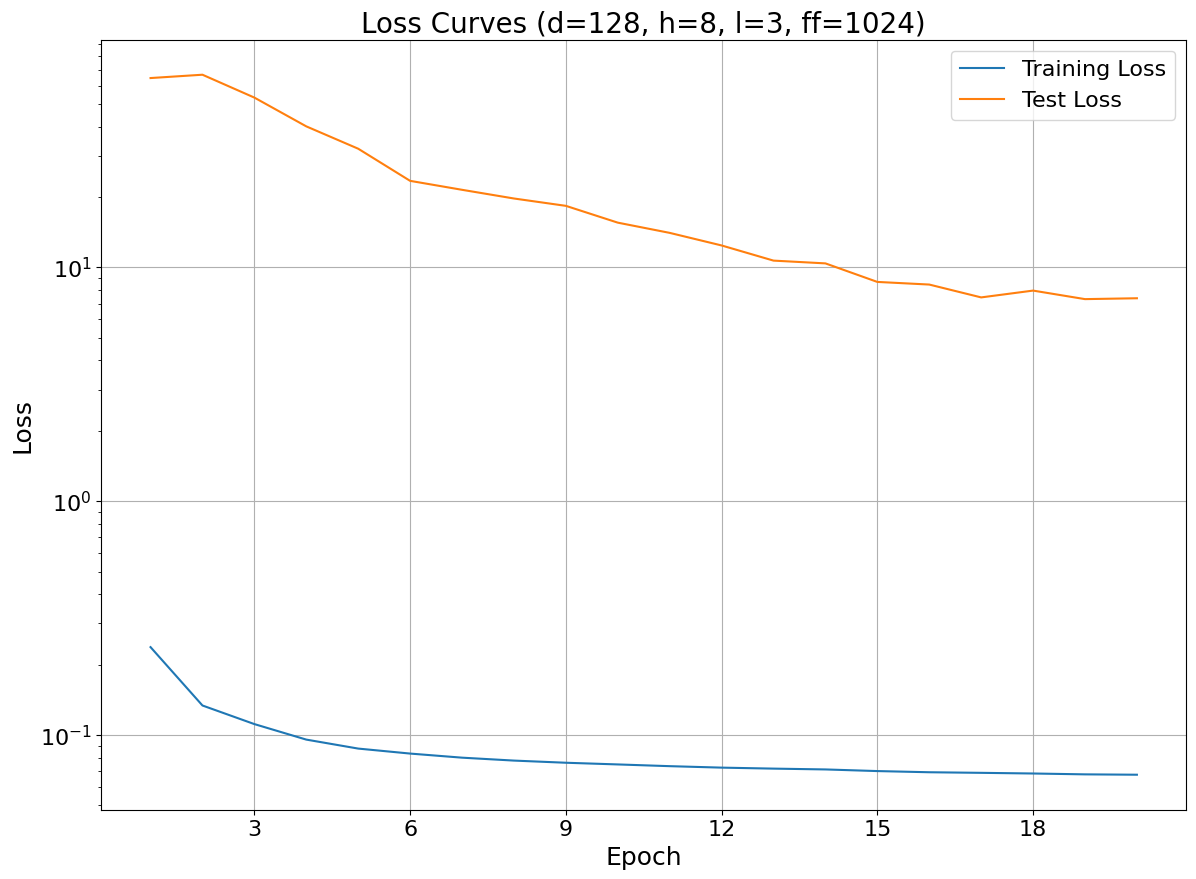

In [74]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: -0.09785598516464233 .. 1.9775073528289795
r_2111 R2:   0.7708
r_2111 MAE:  0.222120
r_2111 RMSE: 0.268989


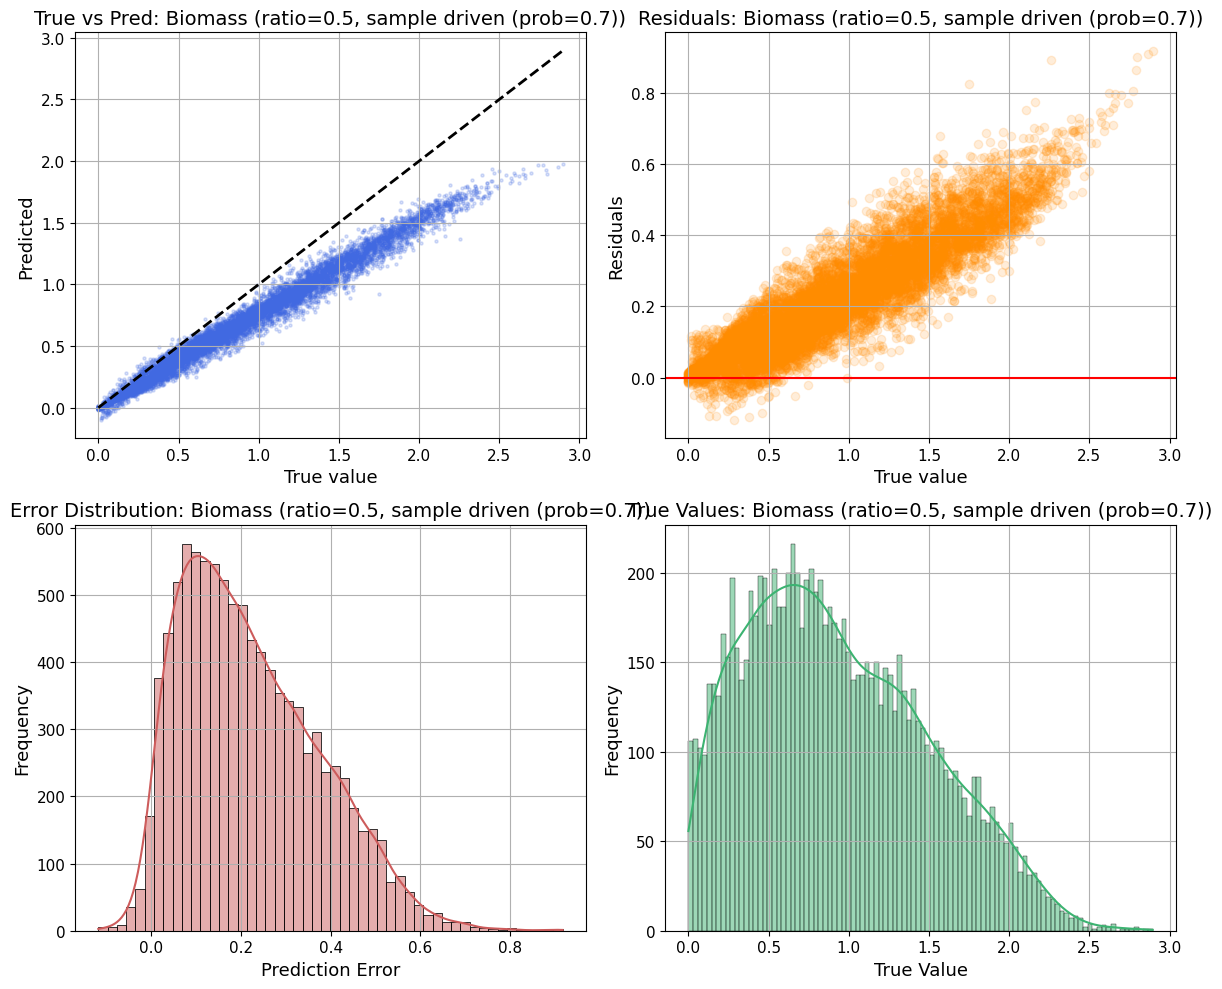

In [75]:
diagnostics_to_plot = ['r_2111']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)

In [76]:
batch_size = 8

metrics = calculate_metrics(model, X_test, y_test, inputs, batch_size=batch_size, device=device)

Overall R2: 0.9021
Overall MAE: 0.0920
Overall RMSE: 1.0544


### Output subset ratio = 0.5

Sample-driven training, sample_prob = 1.0

In [77]:
model_name = "yeast9_d128_h8_l3_ff1024_sample0_5"
sampling_notes = "Sample-driven training, sample_prob = 1.0"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d128_h8_l3_ff1024_sample0_5/yeast9_d128_h8_l3_ff1024_sample0_5_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 1,532,705

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


In [78]:
model.eval()

today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

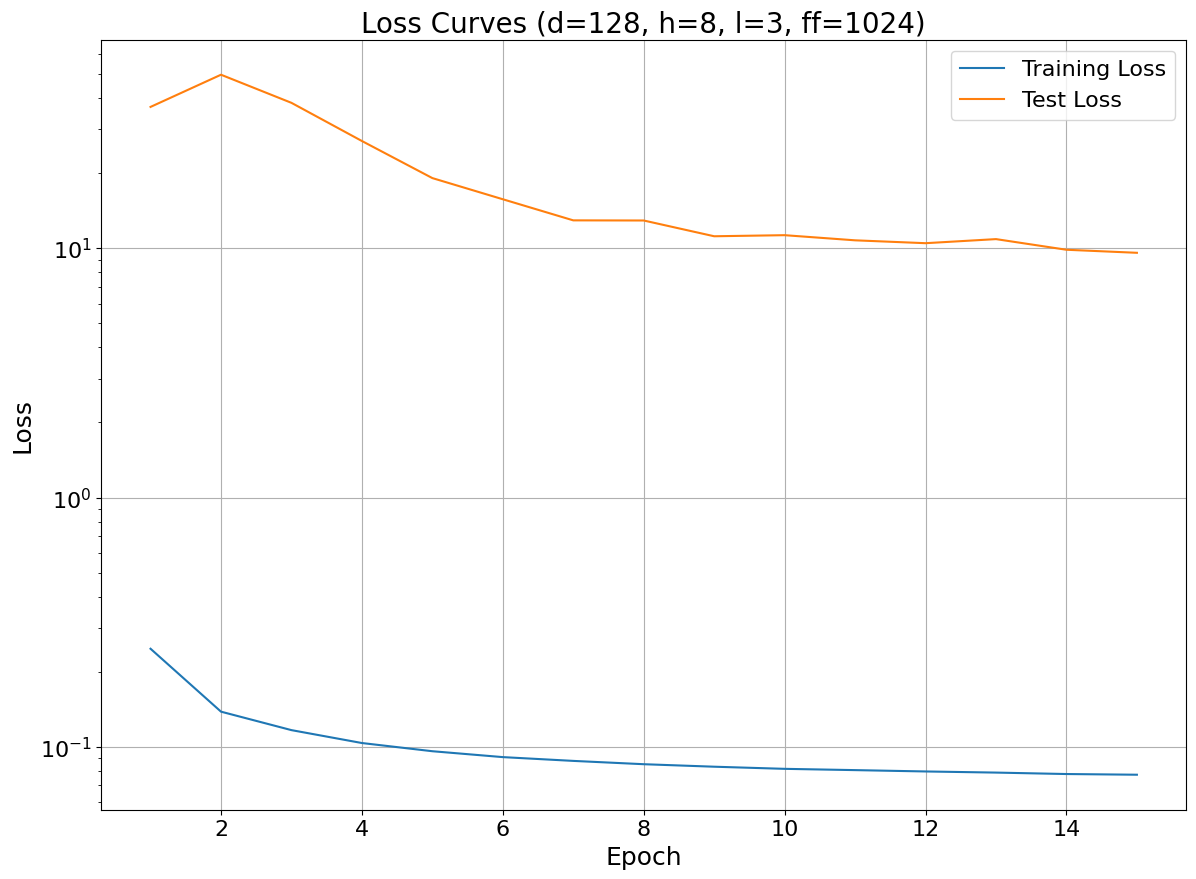

In [79]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: -0.12609779834747314 .. 2.163090705871582
r_2111 R2:   0.5544
r_2111 MAE:  0.329451
r_2111 RMSE: 0.375075


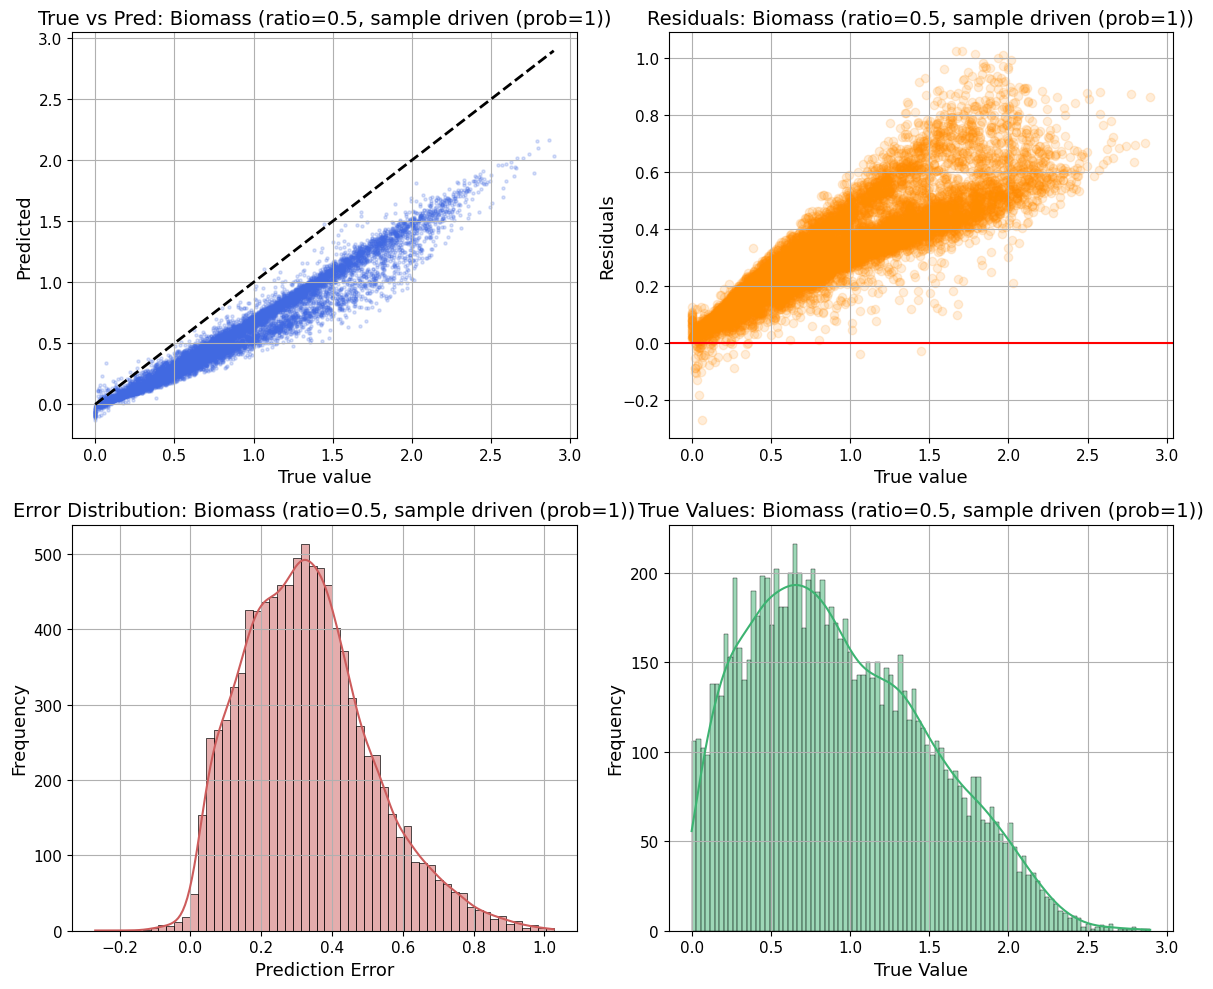

In [80]:
diagnostics_to_plot = ['r_2111']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)

In [81]:
batch_size = 8

metrics = calculate_metrics(model, X_test, y_test, inputs, batch_size=batch_size, device=device)

Overall R2: 0.8789
Overall MAE: 0.1160
Overall RMSE: 1.1731


### Output subset ratio = 0.5

Sample-driven training, epsilon = 0.5

In [82]:
model_name = "yeast9_d128_h8_l3_ff1024_sample0_5_eps0_5"
sampling_notes = "Sample-driven training, epsilon = 0.5, sample_prob = 1.0"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d128_h8_l3_ff1024_sample0_5_eps0_5/yeast9_d128_h8_l3_ff1024_sample0_5_eps0_5_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 1,532,705

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


In [83]:
model.eval()

today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

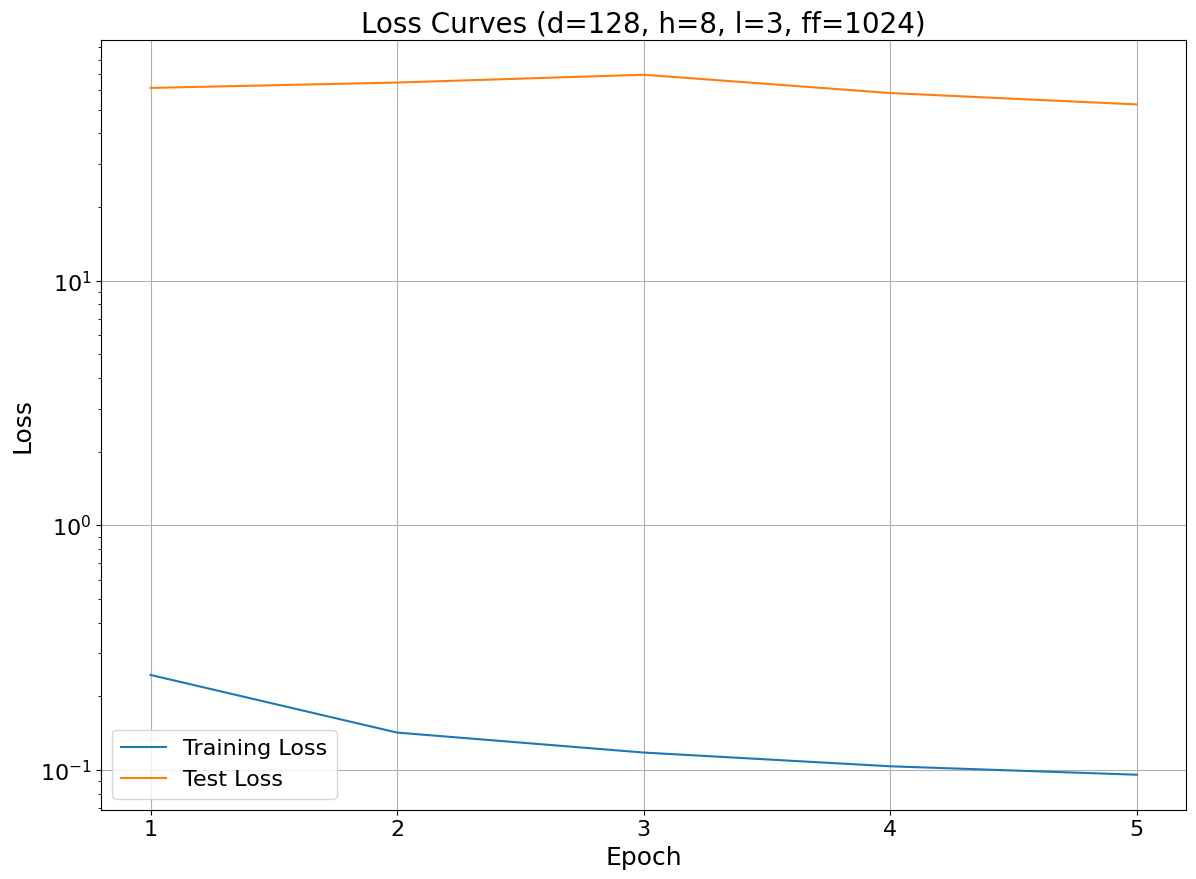

In [84]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: -0.11616766452789307 .. 1.9677650928497314
r_2111 R2:   0.0410
r_2111 MAE:  0.484168
r_2111 RMSE: 0.550248


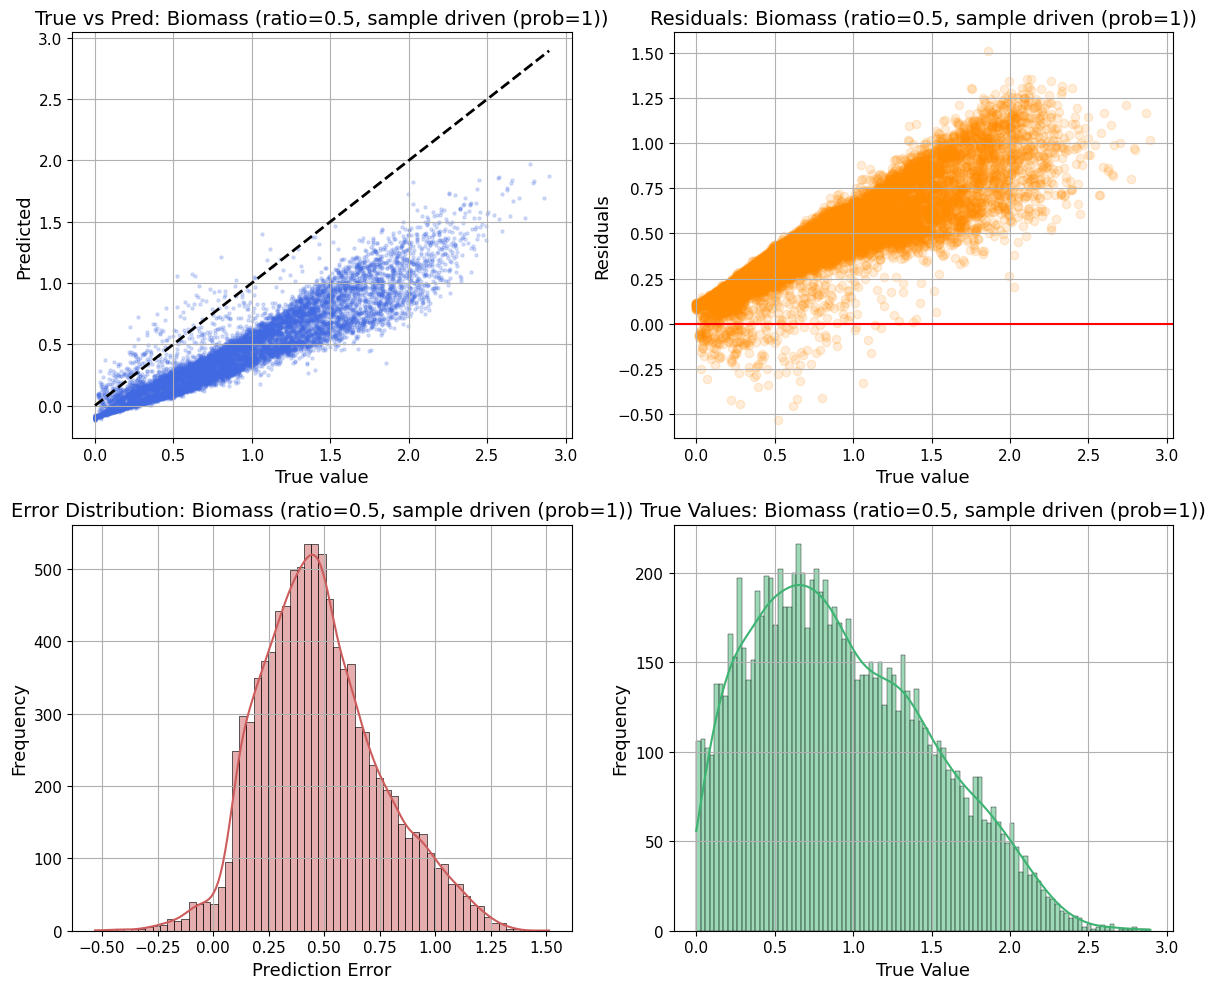

In [85]:
diagnostics_to_plot = ['r_2111']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)